# Task 03 : Classification

Dataset Access Link : https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## 1. Dataset Description

The Breast Cancer Wisconsin (Diagnostic) dataset contains measurements computed from digitized images of breast mass cell nuclei. The objective of this analysis is to classify tumors as benign or malignant using machine learning classification models.

## 2. Data Loading & Cleaning

In [1]:
import numpy as np
import pandas as pd

In [3]:
# Creating a List of Columns for the data set
columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(30)]

In [5]:
# Loading the Data Set
df_bc = pd.read_csv(r"C:\Users\sbast\Downloads\wdbc.csv", header=None, names=columns)

In [7]:
df_bc.head()

,id,diagnosis,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Checking the number of rows and columns 
df_bc.shape

(569, 32)

In [11]:
# Checking the types of data
df_bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    object 
 2   feature_0   569 non-null    float64
 3   feature_1   569 non-null    float64
 4   feature_2   569 non-null    float64
 5   feature_3   569 non-null    float64
 6   feature_4   569 non-null    float64
 7   feature_5   569 non-null    float64
 8   feature_6   569 non-null    float64
 9   feature_7   569 non-null    float64
 10  feature_8   569 non-null    float64
 11  feature_9   569 non-null    float64
 12  feature_10  569 non-null    float64
 13  feature_11  569 non-null    float64
 14  feature_12  569 non-null    float64
 15  feature_13  569 non-null    float64
 16  feature_14  569 non-null    float64
 17  feature_15  569 non-null    float64
 18  feature_16  569 non-null    float64
 19  feature_17  569 non-null    f

In [13]:
# Generating the summary statistics for all numerical features 
df_bc.describe()

,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [15]:
# Counting the number of benign and malignant cases 
df_bc["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [17]:
# Checking for any missing values in the dataset
df_bc.isnull().sum()

id            0
diagnosis     0
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
feature_29    0
dtype: int64

In [19]:
# Checking for any duplicate rows
df_bc.duplicated().sum()

0

## 3. Exploratory Data Analysis (EDA)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

### 3.1 Class Distribution

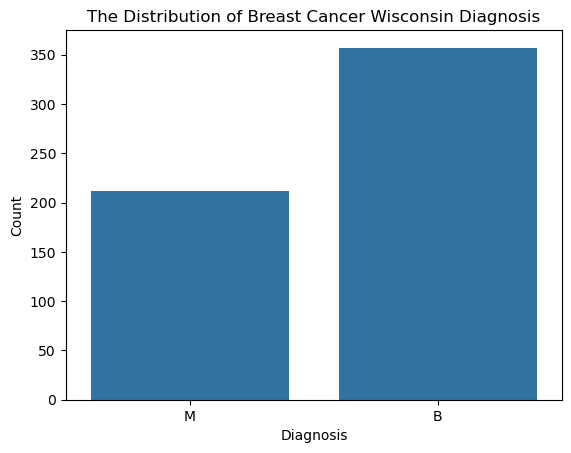

In [24]:
# Plotting the class distribution of benign vs. malignant cases

sns.countplot(x="diagnosis", data=df_bc)
plt.title("The Distribution of Breast Cancer Wisconsin Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

The dataset contains a higher number of benign cases than malidnant cases, indicating a mild class imbalance

### 3.2 Correlation Analysis

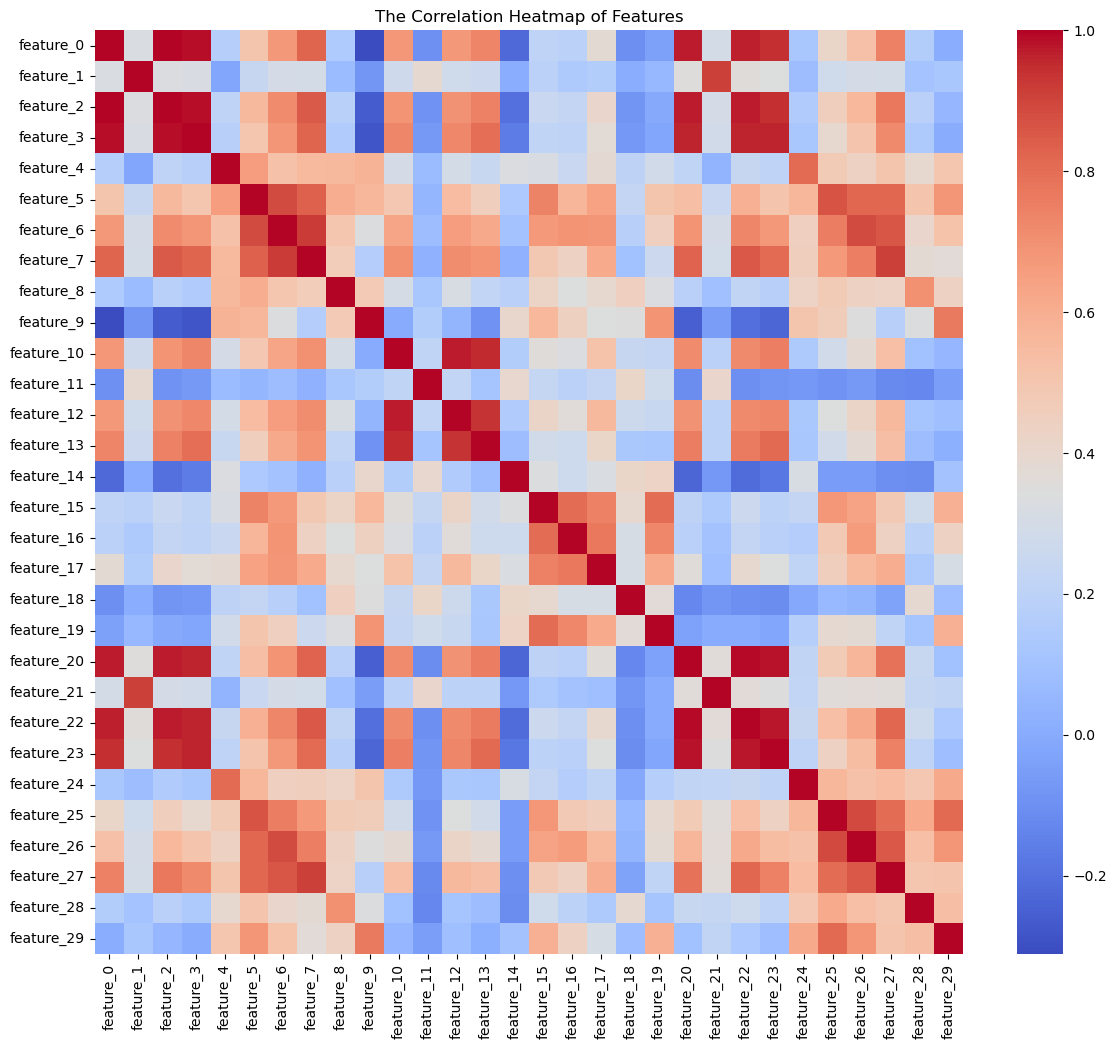

In [29]:
plt.figure(figsize = (14,12))

# Calculating correlations between the numerical features

corr = df_bc.drop(columns=["id","diagnosis"]).corr()

# Visualising the correlations using a heatmap

sns.heatmap(corr, cmap="coolwarm")
plt.title("The Correlation Heatmap of Features")
plt.show()

The heatmap displays the correlation between features, where red indicates strong positive correlation and blue indicates negative correlation. Several features show high correlation with each other, suggesting the presence of multicollinearity and potential redundancy in the dataset.

### 3.3 Feature Distibution

#### 3.3.1 Boxplots

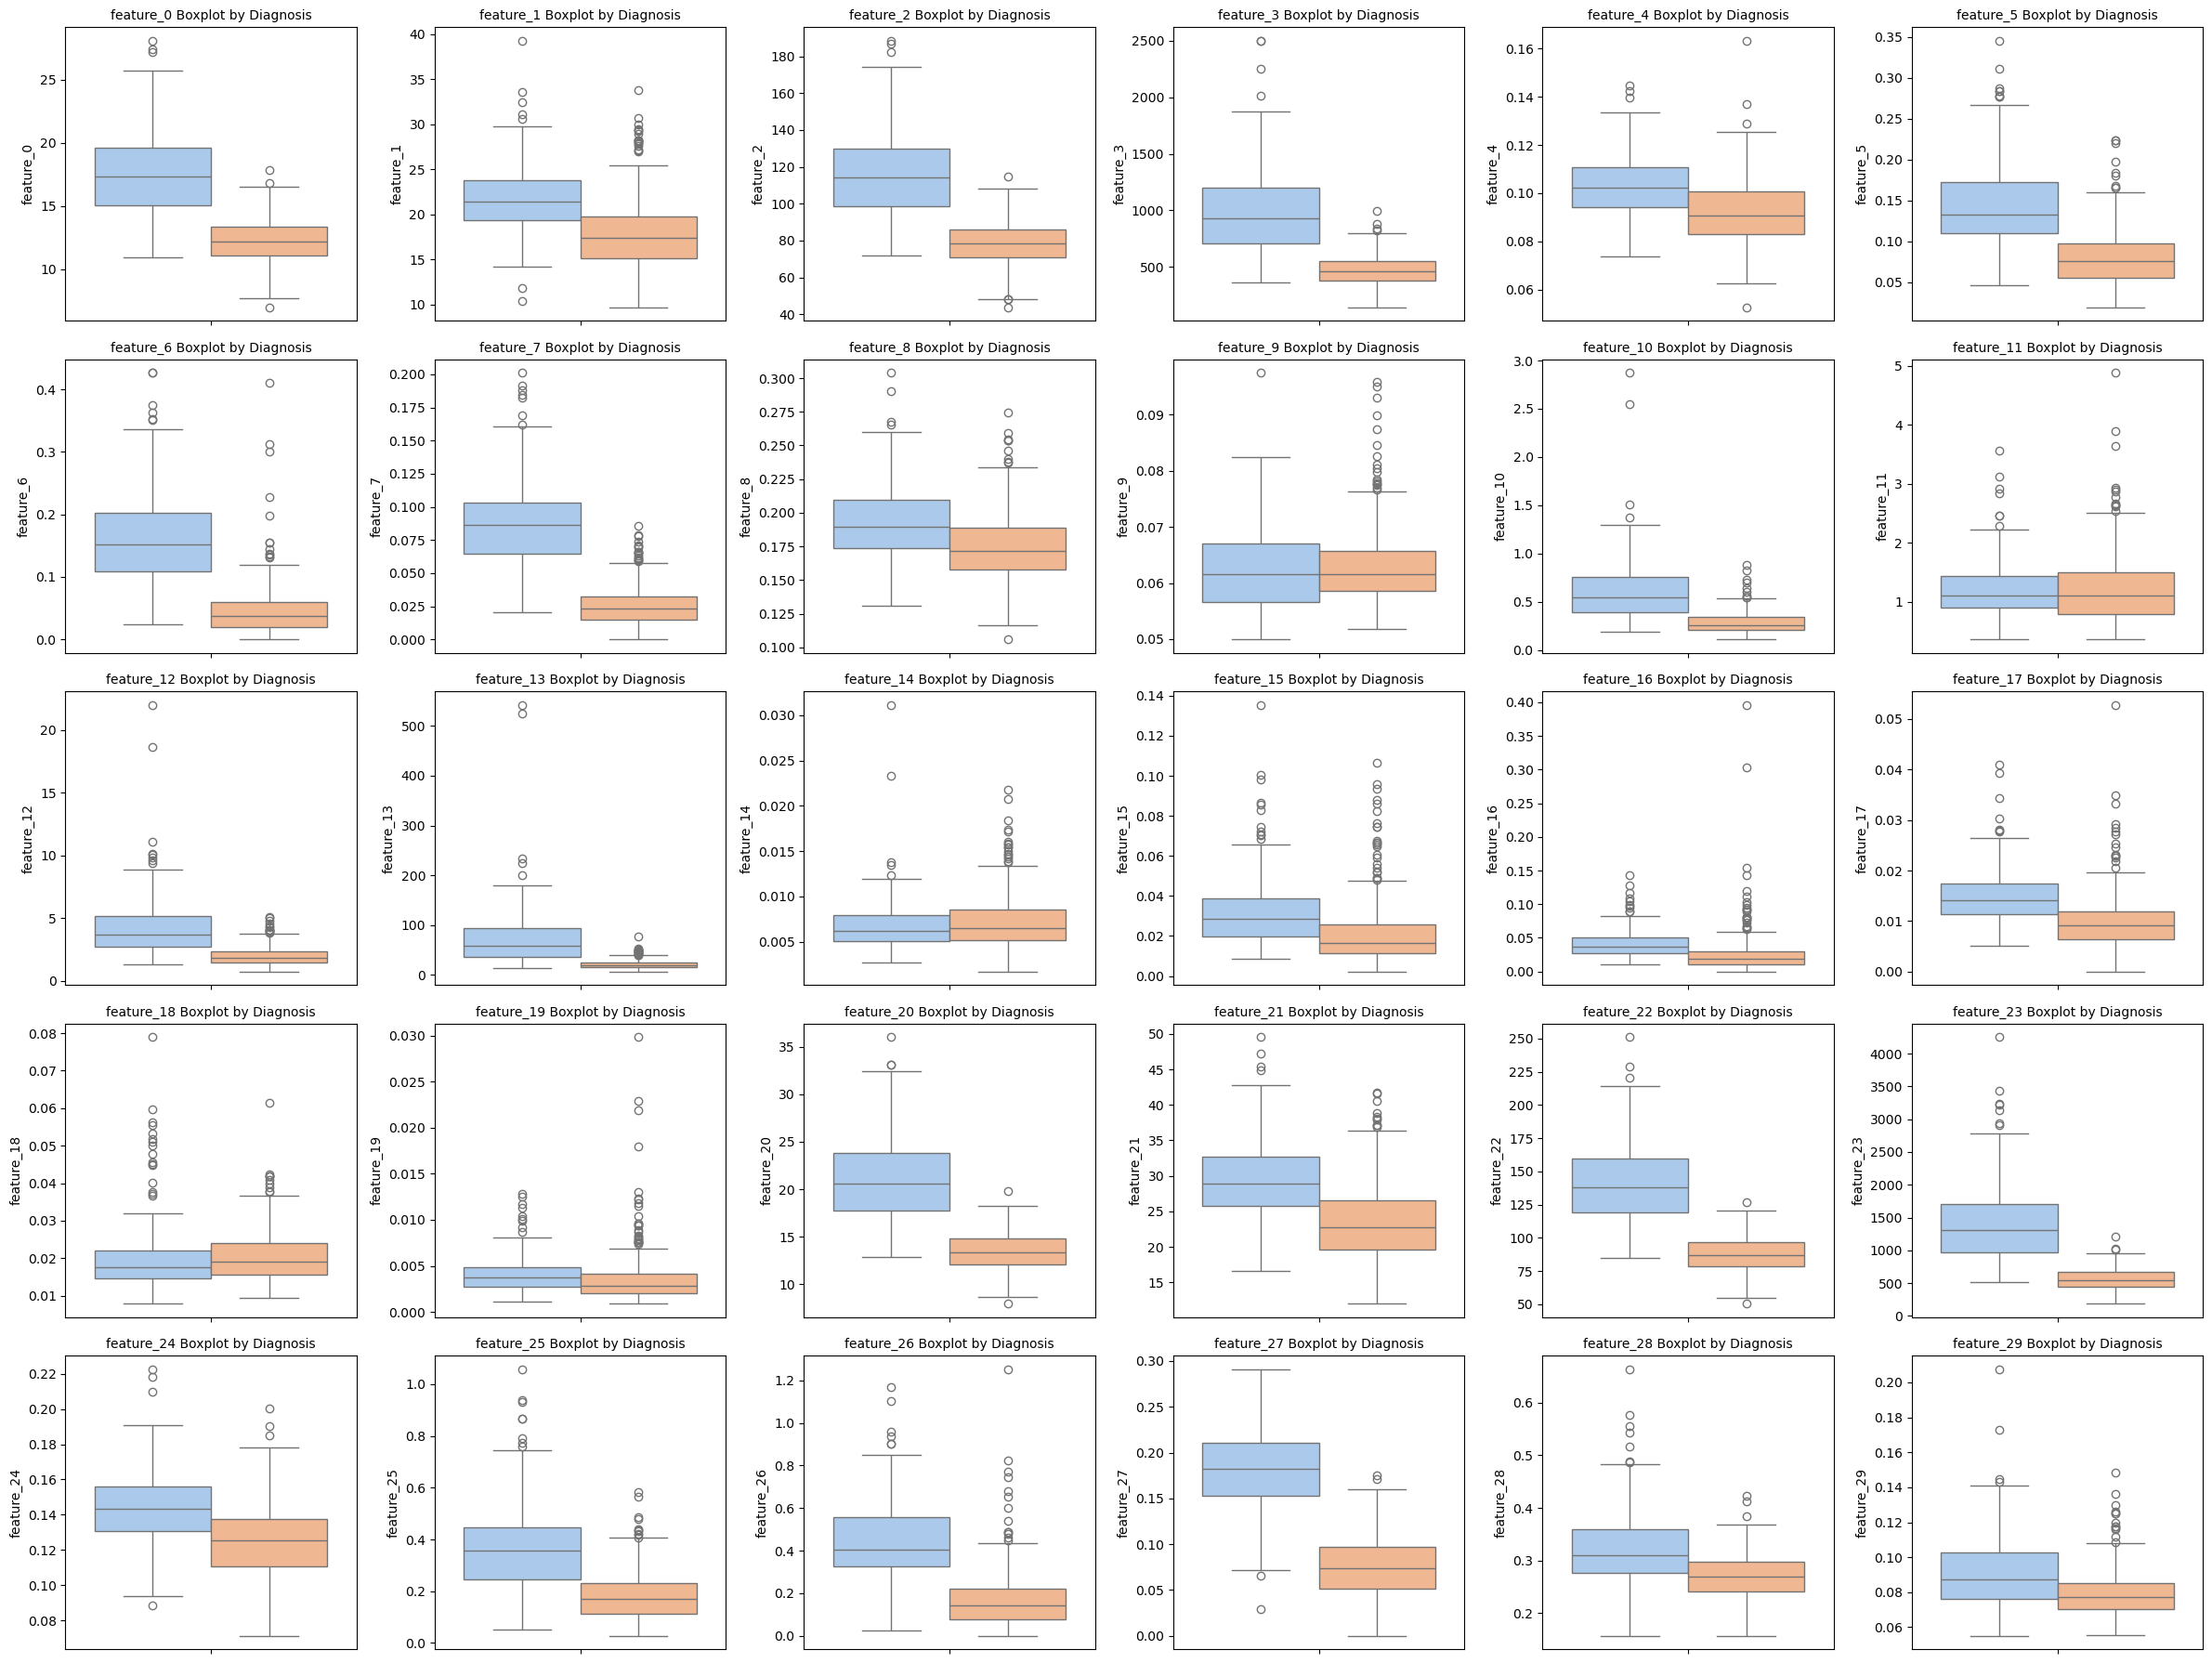

In [33]:
# Selecting all the feature columns 

features = df_bc.drop(columns=["id","diagnosis"]).columns

rows = 5
cols = 6

plt.figure(figsize=(24,18))

for i, feature in enumerate(features): 
    plt.subplot(rows, cols, i+1)

    # Plotting boxplots for each feature by diagnosis
    
    sns.boxplot(hue="diagnosis", y=feature, data=df_bc, palette="pastel",legend=False)
    plt.title(f"{feature} Boxplot by Diagnosis", fontsize=10)

plt.tight_layout()
plt.show()

The boxplots compare the distribution of each feature across the two diagnosis classes. Several features show clear differences in median and spread between the classes, indicating strong discriminatory power. Features with greater separation between the groups are likely to be more useful for classification.

#### 3.3.2 Histogram 

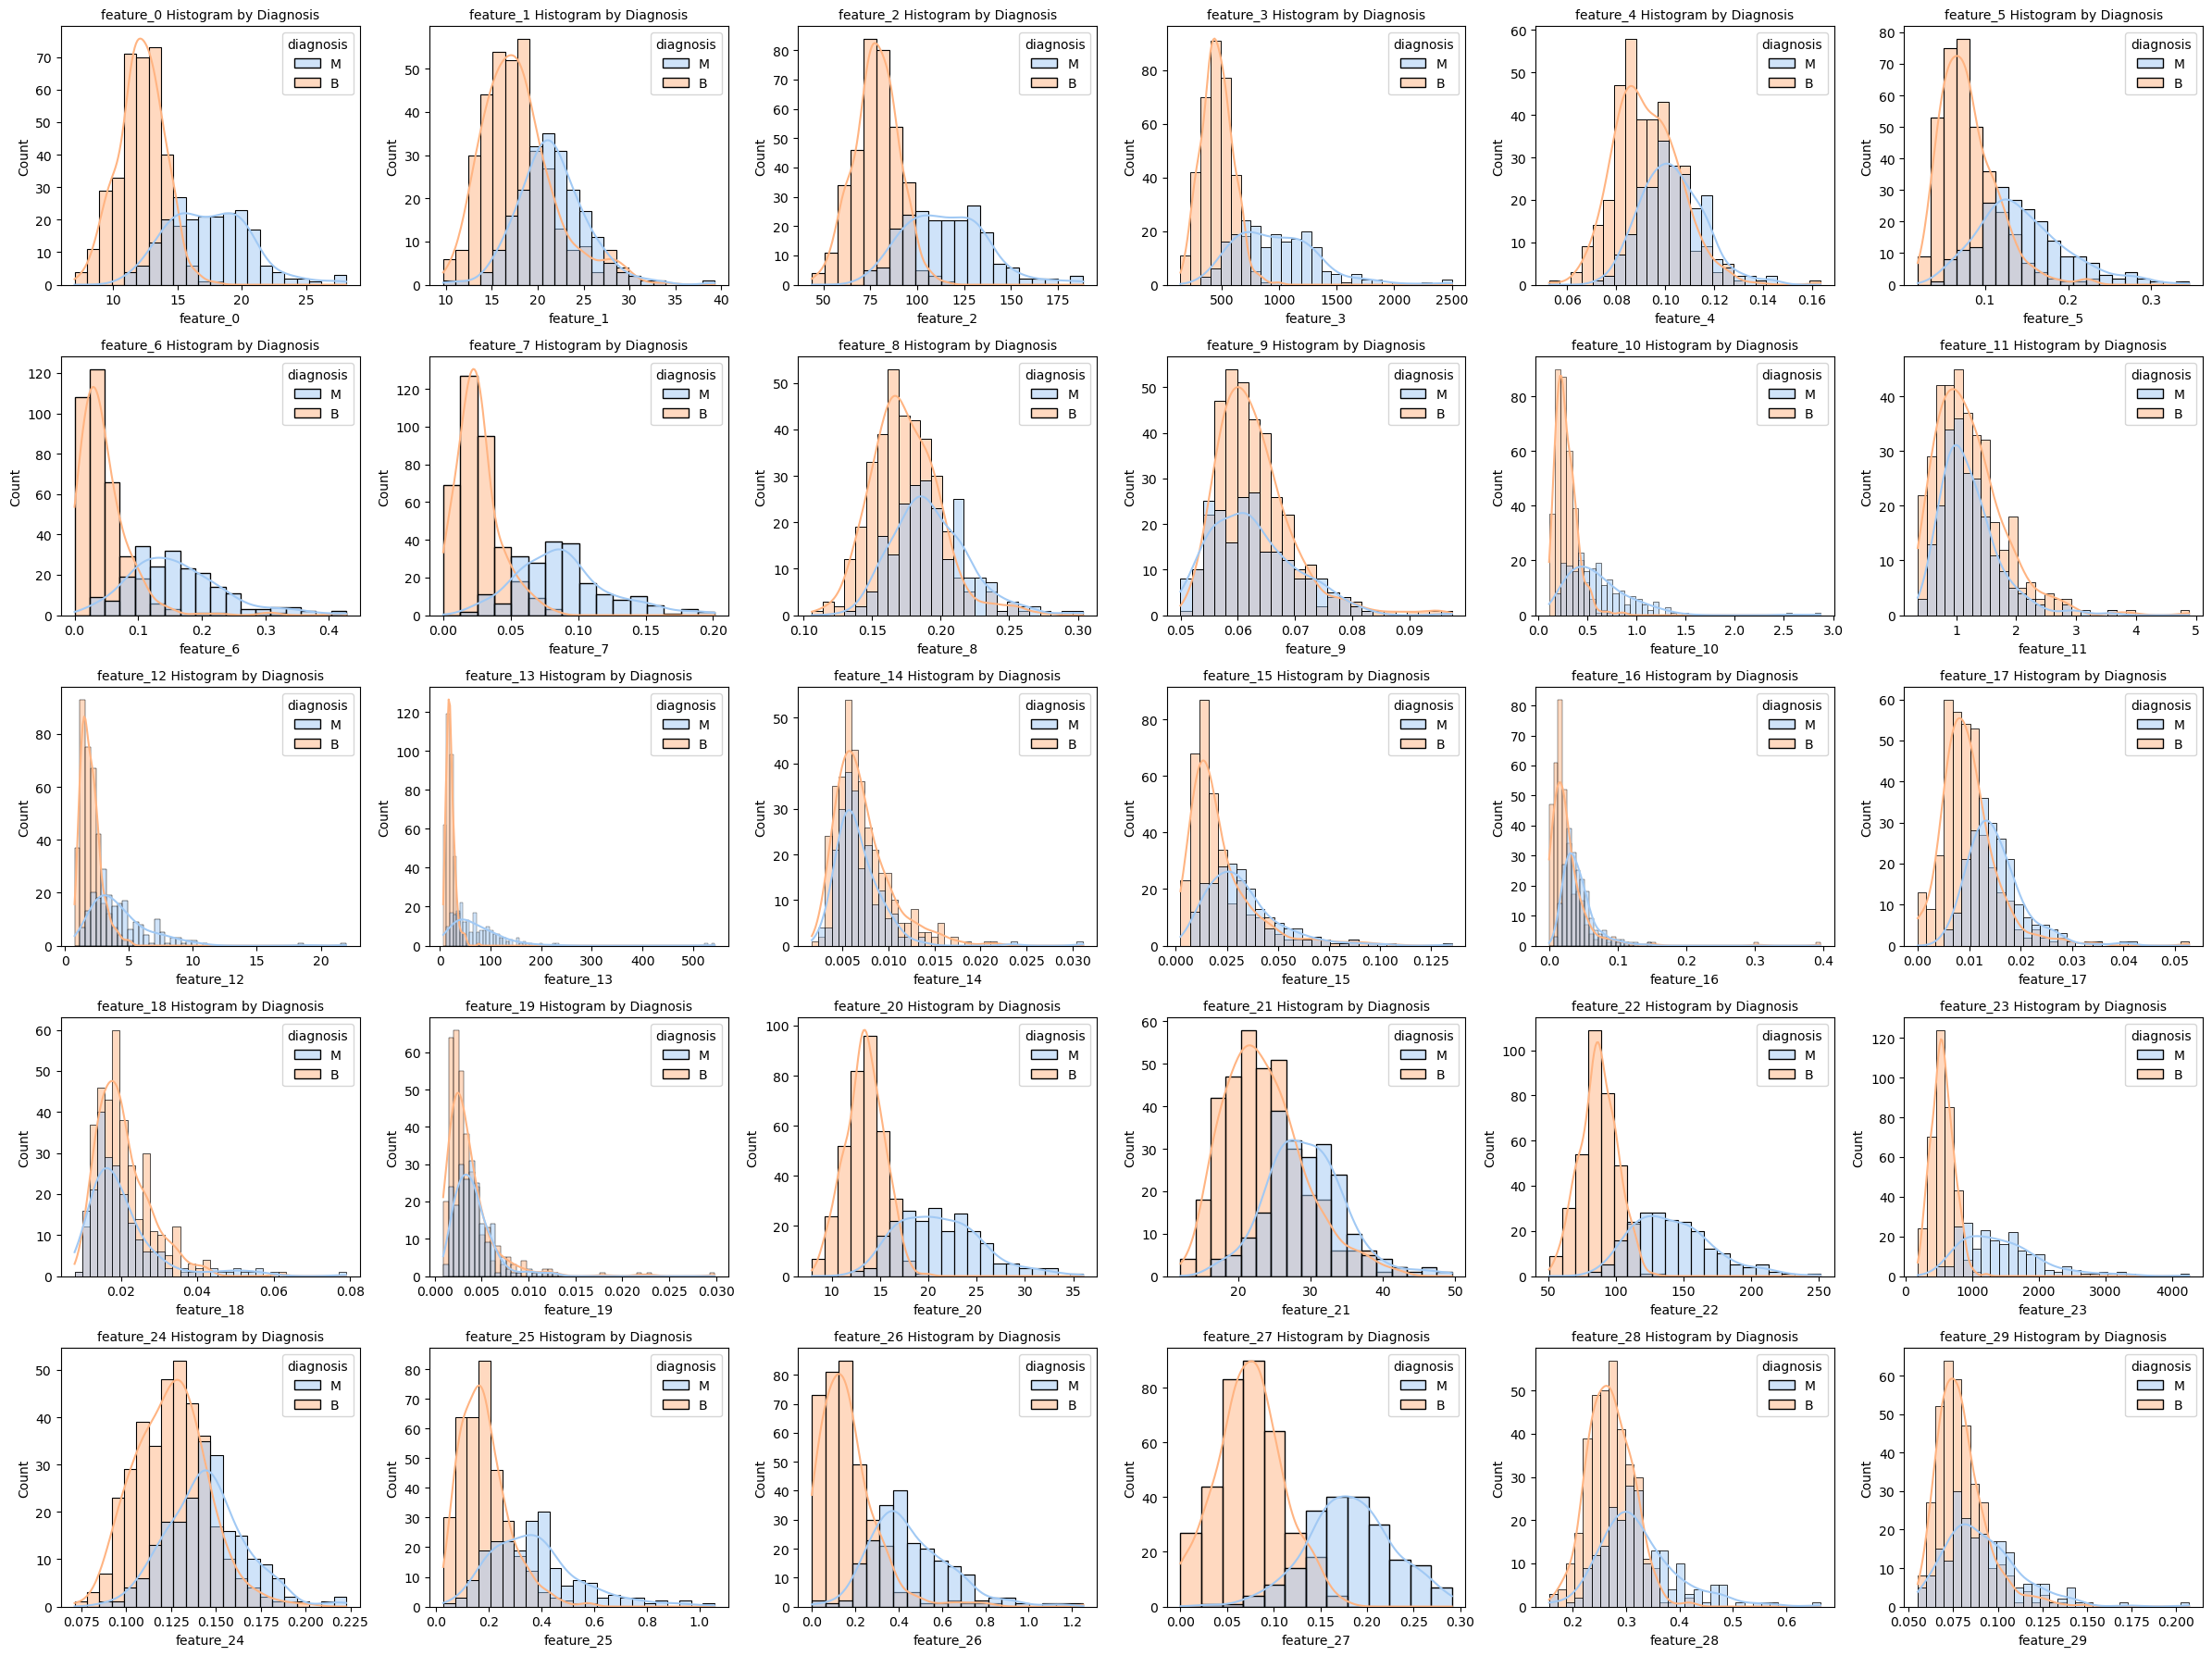

In [36]:
features = df_bc.drop(columns=["id","diagnosis"]).columns

rows = 5
cols = 6

plt.figure(figsize=(24,18))

for i, feature in enumerate(features): 
    plt.subplot(rows, cols, i+1)

    # Plotting histograms to visualise each feature's distribution
    
    sns.histplot(hue="diagnosis", x=feature, data=df_bc, palette="pastel",kde=True)
    plt.title(f"{feature} Histogram by Diagnosis", fontsize=10)

plt.tight_layout()
plt.show()

The histograms show the distribution of each feature for the two diagnosis classes. In several features, the distributions differ noticeably between classes, with shifts in peaks and spread. Features with less overlap between the two distributions are likely to be more useful for classification.

#### 3.3.3 Correlation Table

In [39]:
# Converting diagnosis labels from B/M to numeric values

df_bc["diagnosis"] = df_bc["diagnosis"].map({"B":0, "M":1})

In [41]:
df_bc["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [43]:
# Calculating the correlation of each feature with the diagnosis variables

corr_table = df_bc.drop(columns=["id"]).corr()[["diagnosis"]].sort_values(by="diagnosis", ascending=False)

In [45]:
# Displaying the correlation table 

corr_table

,diagnosis
diagnosis,1.000000
feature_27,0.793566
feature_22,0.782914
feature_7,0.776614
feature_20,0.776454
feature_2,0.742636
feature_23,0.733825
feature_0,0.730029
feature_3,0.708984
feature_6,0.696360


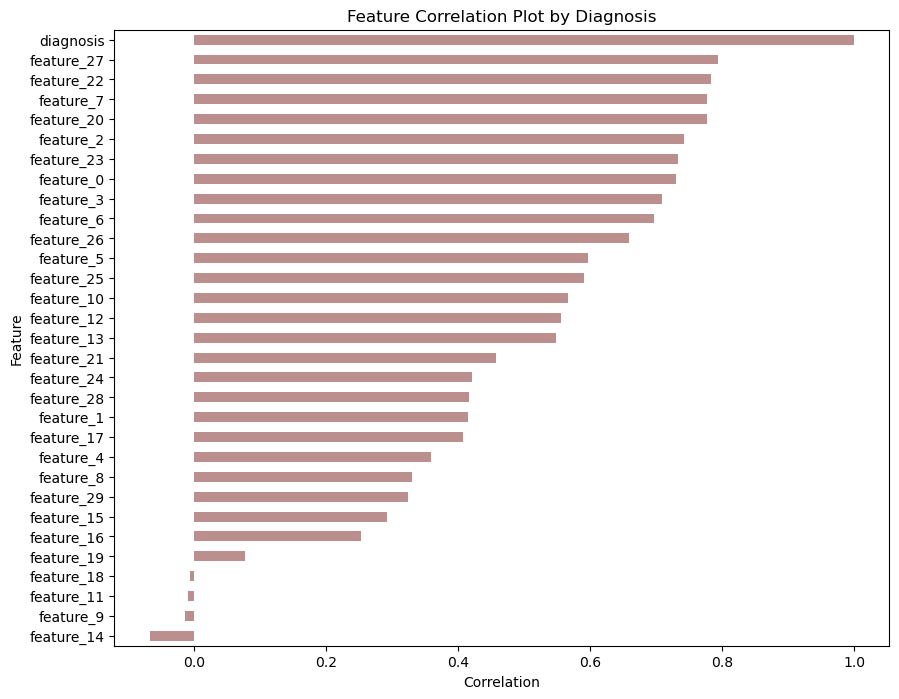

In [47]:
corr_table.sort_values(by="diagnosis").plot(kind="barh", figsize=(10,8), legend=False, color = "rosybrown")

plt.title("Feature Correlation Plot by Diagnosis")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

The plot shows the correlation of each feature with the diagnosis variable. Features with higher positive correlation values are more strongly associated with the target and are likely to be more important for classification. Features with low or near-zero correlation contribute less to distinguishing between the classes.


## 4. Model Training & Evaluation

Feature scaling was applied to Logistic Regression and K-Nearest Neighbours because these algorithms are sensitive to feature magnitude. Tree-based models such as Random Forest and Decision Trees do not require scaling.

In [51]:
df_bc = df_bc.drop(columns=["id"])

In [53]:
# Defining feature variables and target variables

X = df_bc.drop("diagnosis", axis=1)
y = df_bc["diagnosis"]

In [55]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into testing and training data sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [56]:
from sklearn.preprocessing import StandardScaler

# Standardising feature values 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4.1 Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression 

# Training logistic regression classifier 

log_model_bc = LogisticRegression(max_iter = 5000)
log_model_bc.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [61]:
y_pred_log_bc = log_model_bc.predict(X_test_scaled)

#### 4.1.1 Classification Report for the Logistic Regression Model 

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

# Printing the classification report

print(confusion_matrix(y_test, y_pred_log_bc))
print(classification_report(y_test, y_pred_log_bc))

[[71  1]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



The classification report shows high precision and recall for both classes, indicating strong and balanced model performance.

#### 4.1.2 Confusion Matrix for the Logistic Regression Model 

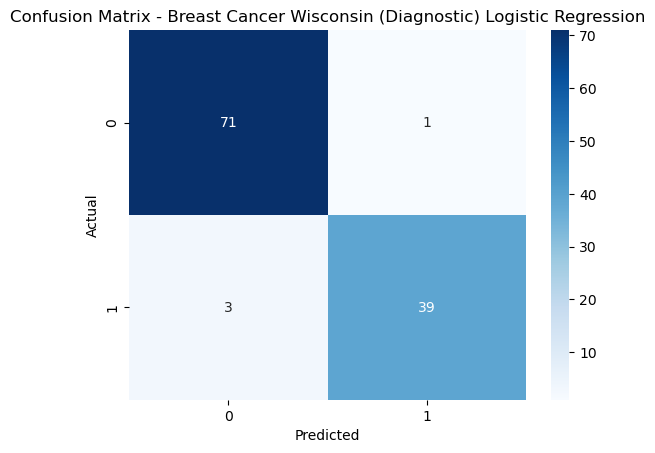

In [65]:
# Plotting the confusion matrix 

sns.heatmap(confusion_matrix(y_test, y_pred_log_bc), annot = True, fmt = "d", cmap = "Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Breast Cancer Wisconsin (Diagnostic) Logistic Regression")

plt.show()

The confusion matrix shows very few misclassifications, confirming the model’s high accuracy in predicting both classes.

#### 4.1.3 ROC Curve For Logistic Regression

In [67]:
# Finding the probabilities to plot the ROC curve

y_prob_log_bc = log_model_bc.predict_proba(X_test_scaled)[:, 1]

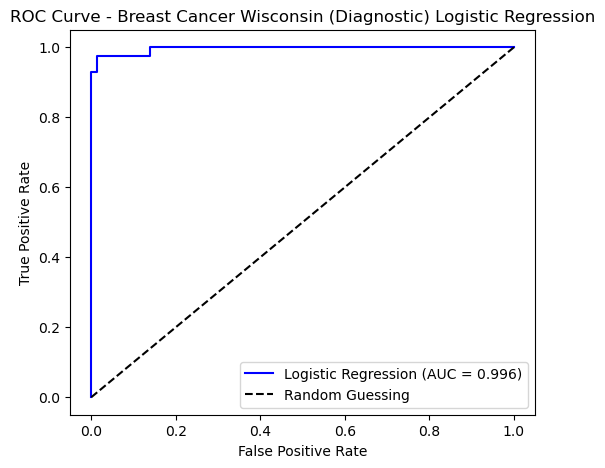

In [69]:
from sklearn.metrics import roc_curve, auc 

# Plotting the ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log_bc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5)) 
plt.plot(fpr, tpr,color = "blue", label = f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label = "Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Wisconsin (Diagnostic) Logistic Regression")
plt.legend()
plt.show()

The ROC curve shows excellent model performance, with an AUC close to 1, indicating a strong ability to distinguish between the two classes.

### 4.2 Random Forest Classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Training the Random Forest Classifier 

rf_model_bc = RandomForestClassifier(random_state = 42)

rf_model_bc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [74]:
y_pred_rf_bc = rf_model_bc.predict(X_test)

#### 4.2.1 Classification Report for the Random Forest Classifier 

In [76]:
# Printing the classification report

print(confusion_matrix(y_test, y_pred_rf_bc))
print(classification_report(y_test, y_pred_rf_bc))

[[72  0]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



The classification report indicates excellent performance with high precision and recall across both classes.

#### 4.2.2 Confusion Matrix for the Random Forest Classifier 

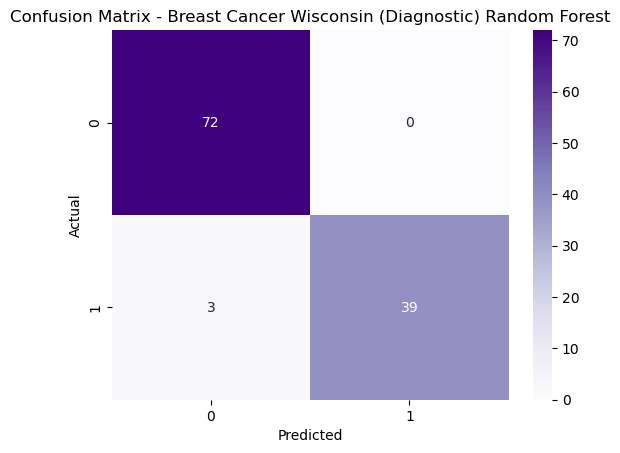

In [78]:
# Plotting the confusion matrix 

sns.heatmap(confusion_matrix(y_test, y_pred_rf_bc), annot = True, fmt = "d", cmap = "Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Breast Cancer Wisconsin (Diagnostic) Random Forest")
plt.show()

The confusion matrix shows almost perfect classification with only a few misclassifications.

#### 4.2.3 ROC Curve for the Random Forest Classifier

In [80]:
# Finding the probabilities to plot the ROC curve

y_prob_rf_bc = rf_model_bc.predict_proba(X_test)[:,1]

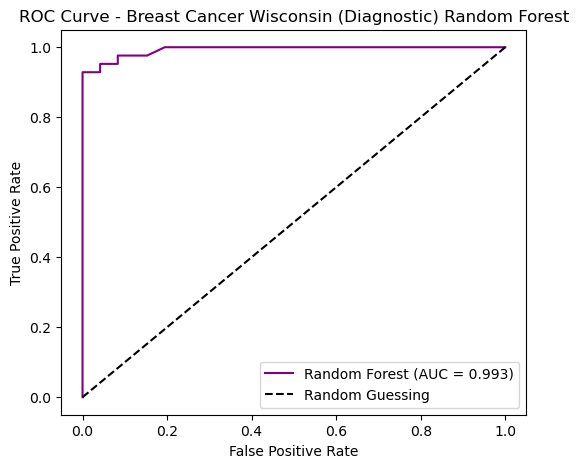

In [82]:
# Plotting the ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf_bc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5)) 
plt.plot(fpr, tpr,color = "purple", label = f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label = "Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Wisconsin (Diagnostic) Random Forest")
plt.legend()
plt.show()

The ROC curve demonstrates strong performance with an AUC close to 1, indicating excellent class separation.

#### 4.2.4 Feature Importance for the Random Forest Classifier 

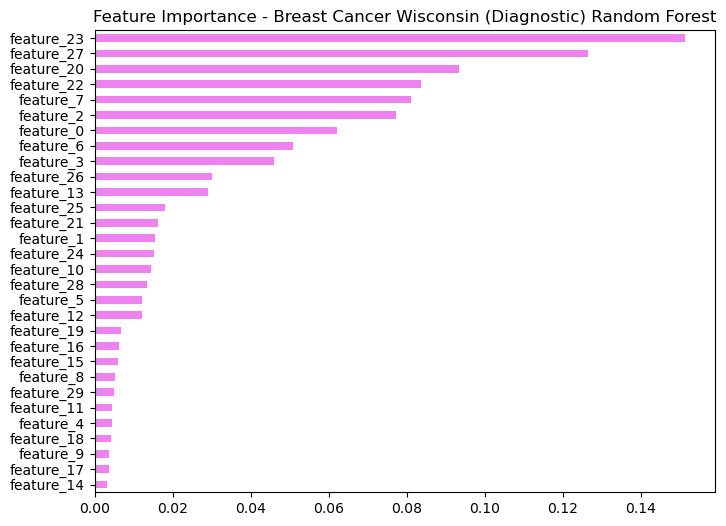

In [84]:
# Plotting a graph for the importance of each feature

importance_bc = rf_model_bc.feature_importances_ # Extracting feature importance scores from the random forest model

pd.Series(importance_bc, index = X.columns).sort_values().plot(kind = "barh", figsize = (8,6), color = "violet") 

plt.title("Feature Importance - Breast Cancer Wisconsin (Diagnostic) Random Forest")

plt.xlabel("Importance Score")

plt.show()

Feature importance analysis indicates that several radius and texture measurements contribute strongly to the classification of malignant tumors. These predictors appear to play a key role in distinguishing malignant and benign cases.

### 4.3 Decision Tree Classifier

In [88]:
from sklearn.tree import DecisionTreeClassifier

# Training the decision tree classifier

dt_model_bc = DecisionTreeClassifier(random_state = 42)

dt_model_bc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [90]:
y_pred_dt_bc = dt_model_bc.predict(X_test)

#### 4.3.1 Classification Report for the Decision Tree Classifier

In [92]:
# Printing the classification report

print(confusion_matrix(y_test, y_pred_dt_bc))
print(classification_report(y_test, y_pred_dt_bc))

[[68  4]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



The classification report shows good performance, though slightly lower than other models.

#### 4.3.2 Confusion Matrix for The Decision Trees Classifier

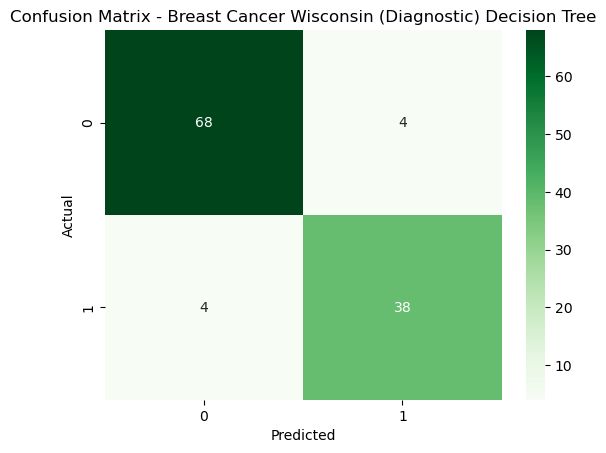

In [95]:
# Plotting the confusion matrix

sns.heatmap(confusion_matrix(y_test, y_pred_dt_bc), annot = True, fmt = "d", cmap = "Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Breast Cancer Wisconsin (Diagnostic) Decision Tree")
plt.show()

The confusion matrix indicates more misclassifications compared to other models, suggesting lower accuracy.

#### 4.3.3 ROC Curve for the Decision Trees Classifier

In [98]:
# Finding the probabilities to plot the ROC curve

y_prob_dt_bc = dt_model_bc.predict_proba(X_test)[:,1]

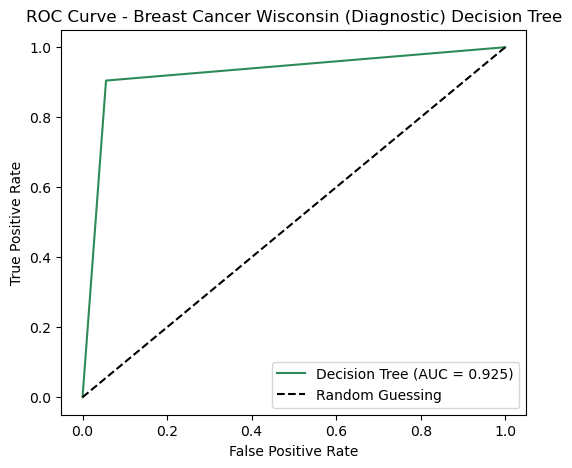

In [100]:
# Plotting the ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt_bc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5)) 
plt.plot(fpr, tpr,color = "seagreen", label = f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label = "Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Wisconsin (Diagnostic) Decision Tree")
plt.legend()
plt.show()

The ROC curve shows reasonable performance, but with a lower AUC compared to more advanced models.

### 4.4 K - Nearest Neighbors

In [103]:
from sklearn.neighbors import KNeighborsClassifier

# Training the K-Nearest Neighbours Classifier

knn_model_bc = KNeighborsClassifier(n_neighbors = 5)

knn_model_bc.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [105]:
y_pred_knn_bc = knn_model_bc.predict(X_test_scaled)

#### 4.4.1 Classification Report for the K - Nearest Neighbours 

In [106]:
# Printing the classification report 

print(confusion_matrix(y_test, y_pred_knn_bc))
print(classification_report(y_test, y_pred_knn_bc))

[[71  1]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



The classification report shows strong performance with high precision and recall for both classes.

#### 4.4.2 Confusion Matrix for the K - Nearest Neighbours

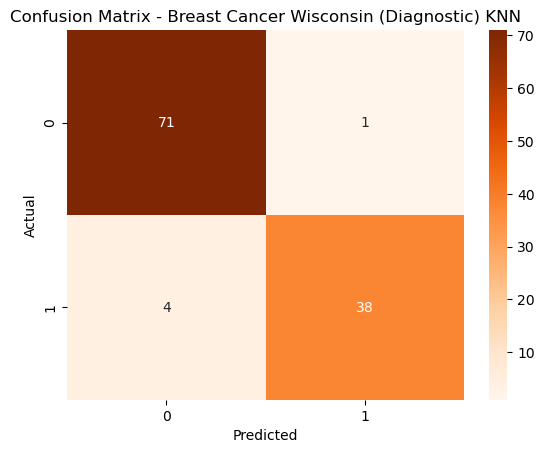

In [109]:
#Plotting the confusion matrix

sns.heatmap(confusion_matrix(y_test, y_pred_knn_bc), annot = True, fmt = "d", cmap = "Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Breast Cancer Wisconsin (Diagnostic) KNN")
plt.show()

The confusion matrix shows a small number of misclassifications, indicating good predictive accuracy.

#### 4.4.3 ROC Curve for the K - Nearest Neighbours

In [111]:
# Finding the probabilities to plot the ROC curve

y_prob_knn_bc = knn_model_bc.predict_proba(X_test_scaled)[:,1]

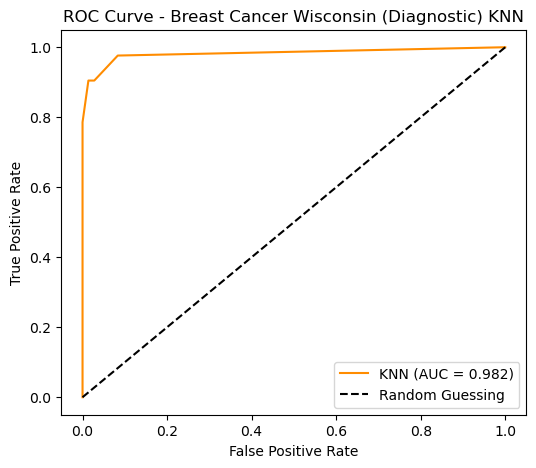

In [113]:
# Plotting the ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn_bc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5)) 
plt.plot(fpr, tpr,color = "darkorange", label = f"KNN (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label = "Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Wisconsin (Diagnostic) KNN")
plt.legend()
plt.show()

The ROC curve indicates strong performance with a high AUC, though slightly lower than Logistic Regression and Random Forest.

## 5. Model Comparison

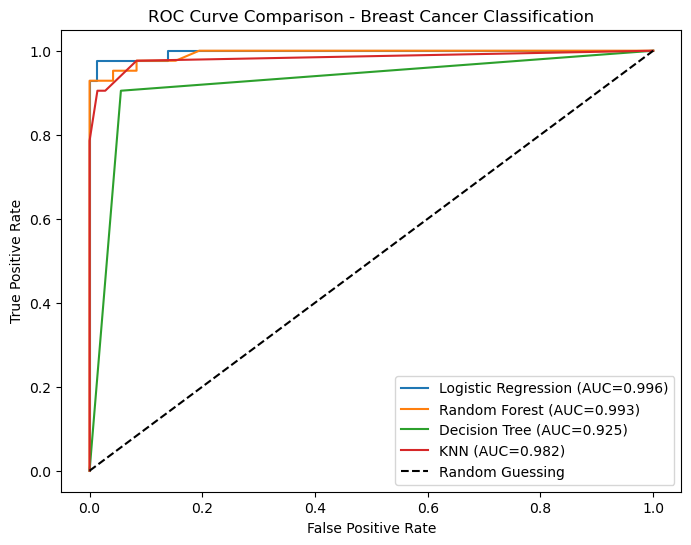

In [116]:
# Plotting an ROC curve comparision graph 

plt.figure(figsize = (8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_bc)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc(fpr_log,tpr_log):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_bc)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc(fpr_rf,tpr_rf):.3f})")

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt_bc)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc(fpr_dt,tpr_dt):.3f})")

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_bc)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc(fpr_knn,tpr_knn):.3f})")

# Random guessing line
plt.plot([0,1], [0,1], "k--", label="Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Breast Cancer Classification")
plt.legend()
plt.show()

The ROC curves compare the classification performance of all models. Logistic Regression and Random Forest achieve the highest AUC values, indicating superior ability to distinguish between classes. Decision Tree performs the weakest, while KNN still shows strong performance.

In [118]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Creating a table to compare model performance metrics

results_bc = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "Decision Tree", "KNN"], 
                        "Accuracy" : [accuracy_score(y_test, y_pred_log_bc), accuracy_score(y_test, y_pred_rf_bc), accuracy_score(y_test, y_pred_dt_bc), accuracy_score(y_test, y_pred_knn_bc)], 
                        "Precision" : [precision_score(y_test, y_pred_log_bc), precision_score(y_test, y_pred_rf_bc), precision_score(y_test, y_pred_dt_bc), precision_score(y_test, y_pred_knn_bc)], 
                        "Recall" : [recall_score(y_test, y_pred_log_bc), recall_score(y_test, y_pred_rf_bc), recall_score(y_test, y_pred_dt_bc), recall_score(y_test, y_pred_knn_bc)], 
                        "F1-Score" : [f1_score(y_test, y_pred_log_bc), f1_score(y_test, y_pred_rf_bc), f1_score(y_test, y_pred_dt_bc), f1_score(y_test, y_pred_knn_bc)]})
                         

In [120]:
# Printing the performance table 

results_bc.set_index("Model").round(3)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.965,0.975,0.929,0.951
Random Forest,0.974,1.000,0.929,0.963
Decision Tree,0.930,0.905,0.905,0.905
KNN,0.956,0.974,0.905,0.938


The table summarises key performance metrics across models. Random Forest achieves the highest accuracy and precision, while Logistic Regression and KNN also demonstrate strong and consistent performance. Decision Tree shows comparatively lower performance across all metrics.

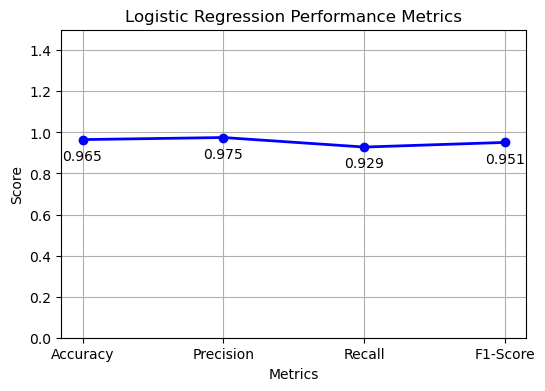

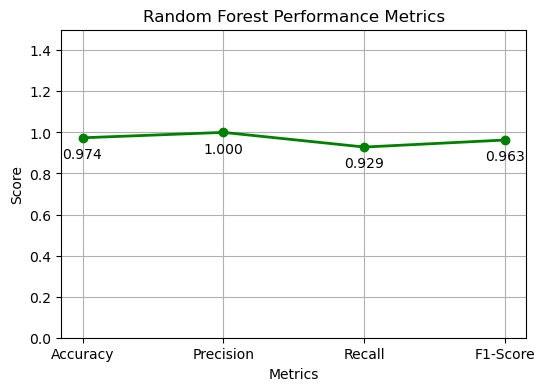

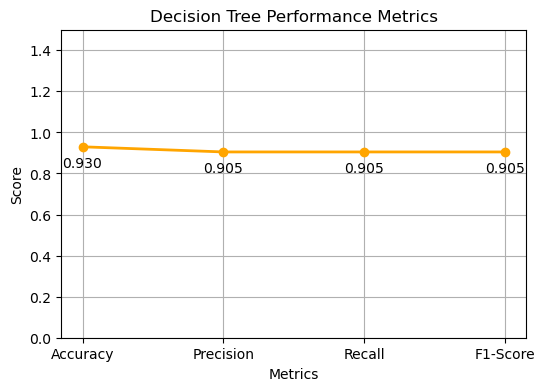

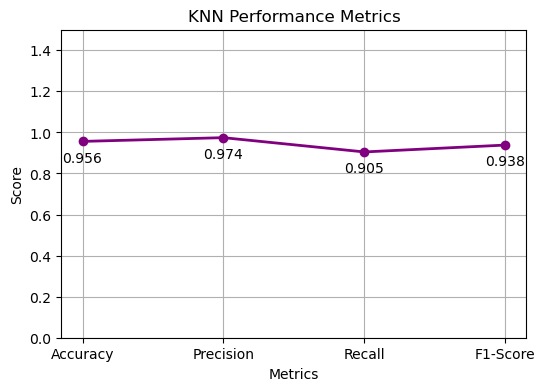

In [122]:
# Comparing all metrics for each classification by plotting each individually as line graphs

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["blue", "green", "orange", "purple"]

for i in range(len(results_bc)): 
    plt.figure(figsize = (6,4))
    
    values = results_bc.loc[i, metrics]
    
    plt.plot(metrics, values, color = colors[i], linewidth = 2, marker = "o")

    for x, y in zip(metrics, values): 
        plt.text(x, y-0.1, f"{y:.3f}", ha = "center")
        
    plt.title(f"{results_bc.loc[i, 'Model']} Performance Metrics")
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.ylim(0,1.5)
    plt.grid(True)
    plt.show()

Logistic Regression demonstrates consistently high performance across all metrics. Precision is   slightly higher than recall, indicating the model is very accurate in its predictions while maintaining good sensitivity.

Random Forest shows the strongest overall performance, achieving the highest accuracy and perfect precision. This indicates the model is highly reliable, with very few false positive predictions.

Decision Tree exhibits lower performance compared to other models. The metrics are more balanced but consistently lower, suggesting the model may be underfitting or less capable of capturing complex patterns.

KNN performs well across all metrics, with strong precision and accuracy. However, it slightly underperforms compared to Logistic Regression and Random Forest, particularly in recall.

## 6. Cross Validation 

In [125]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [127]:
# Displaying the first 10 values of the diagnosis column

df_bc["diagnosis"].head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: diagnosis, dtype: int64

In [129]:
# Checking the unique values present in the diagnosis column 

df_bc["diagnosis"].unique()

array([1, 0], dtype=int64)

In [131]:
# Counting the number of occurences of each diagnosis column

df_bc["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [133]:
# Seoerating input features (x) from target variable (y)

x = df_bc.drop(columns = ["id", "diagnosis"], errors = "ignore")
y = df_bc["diagnosis"]

In [135]:
# Checking the type and contents of the target variable 

print(type(y))
print(y.head())
print(y.unique())

<class 'pandas.core.series.Series'>
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64
[1 0]


### 6.1 Cross Validation Table for all Models

In [137]:
# Creating a stratified 5-fold cross-validation stratergy 

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
models_cv_bc = {"Logistic Regression": make_pipeline(StandardScaler(), log_model_bc), 
                "Random Forest" : rf_model_bc, 
                "Decision Tree" : dt_model_bc, 
                "KNN" : make_pipeline(StandardScaler(), knn_model_bc)}

# Creating an empty list to store cross-validation results 

results_cv_bc = []

# Preforming corss-validation for each model 

for name, model in models_cv_bc.items():
    
    cv_scores_bc = cross_val_score(model, X, y, cv=cv, scoring = "accuracy") # Computing the accuracy scores

    # Storing the mean accuracy and standard deviation for each model
    
    results_cv_bc.append({"Model":name, "CV Mean Accuracy":cv_scores_bc.mean(), "CV Std Dev": cv_scores_bc.std()})

# Converting the cross-validation results into a dataframe

cv_table_bc = pd.DataFrame(results_cv_bc)

# Displaying cross-validation results

cv_table_bc

,Model,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.973669,0.016627
1,Random Forest,0.954339,0.012822
2,Decision Tree,0.910402,0.027876
3,KNN,0.963096,0.017886


The cross-validation results provide a more robust evaluation of model performance. Logistic Regression achieves the highest mean accuracy with low variability, indicating stable and reliable performance across folds.

### 6.2 AUC Score Comparison Table of all Models

In [140]:
from sklearn.metrics import roc_auc_score

# Creating a table to compare AUC scores across models

roc_results_bc = pd.DataFrame({"Model" : ["Logistic Regression", "Random Forest", "Decision Tree", "KNN"], 
                            "AUC" : [roc_auc_score(y_test, y_prob_log_bc), roc_auc_score(y_test, y_prob_rf_bc), roc_auc_score(y_test, y_prob_dt_bc), roc_auc_score(y_test, y_prob_knn_bc)]})

# Displaying AUC comparison table 

roc_results_bc

,Model,AUC
0,Logistic Regression,0.996032
1,Random Forest,0.992890
2,Decision Tree,0.924603
3,KNN,0.982308


The AUC scores confirm that Logistic Regression has the best overall classification performance. Random Forest and KNN follow closely, while Decision Tree shows comparatively lower discriminative ability.

## 7. Conclusion

Among the evaluated models, Random Forest achieved the highest performance across most evaluation metrics, including accuracy, precision, and F1-score. This is likely due to its ability to capture complex, non-linear relationships and reduce overfitting through ensemble learning. 

Logistic Regression also performed strongly, indicating that the dataset is well separated and can be effectively modelled using a linear classifier. Overall, ensemble methods such as Random Forest provide highly reliable predictions, while Logistic Regression offers a strong and stable alternative. 

The high overall accuracy suggests that the selected features are highly informative for distinguishing between malignant and benign cases. Furthermore, the strong recall values are particularly important in this context, as correctly identifying malignant cases is critical in medical diagnosis.